# GEOG 592 — Week 7 Homework
## GeoPandas Geoprocessing Techniques



In [4]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

### Layer 1: Chargers in Chapel Hill and Surrounding Counties (Within)

In [5]:
# Read data
raw_chargers = gpd.read_file("data/chargers.geojson")

raw_chargers

,access_code,access_days_time,access_detail_code,cards_accepted,date_last_confirmed,expected_date,fuel_type_code,groups_with_access_code,id,maximum_vehicle_class,...,nps_unit_name,access_days_time_fr,intersection_directions_fr,bd_blends_fr,groups_with_access_code_fr,ev_pricing_fr,ev_charging_units,ev_network_ids,federal_agency,geometry
0,public,24 hours daily; metered parking,NaN,NaN,2026-06-12,None,ELEC,Public,39016,MD,...,NaN,None,None,None,Public,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN,POINT (-78.64347 35.77842)
1,public,24 hours daily,NaN,NaN,2026-06-12,None,ELEC,Public,39017,LD,...,NaN,None,None,None,Public,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN,POINT (-78.64229 35.77435)
2,public,Dealership business hours,CALL,NaN,2024-02-12,None,ELEC,Public - Call ahead,40066,LD,...,NaN,None,None,None,Public - Appeler à l'avance,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN,POINT (-80.62277 35.39209)
3,public,24 hours daily; for guest use only,NaN,NaN,2026-09-14,None,ELEC,Public,40745,LD,...,NaN,None,None,None,Public,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN,POINT (-78.6385 35.77288)
4,public,24 hours daily; pay garage,NaN,NaN,2026-06-12,None,ELEC,Public,40747,LD,...,NaN,None,None,None,Public,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN,POINT (-78.64149 35.77262)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1879,public,Mon: 7:00am-3:00pm; Tue: 7:00am-3:00pm; Wed: 7...,NaN,NaN,2026-10-04,None,ELEC,Public,470511,NaN,...,NaN,None,None,None,Public,None,"[{'network': 'ChargePoint Network', 'connector...","{'station': ['USCPIL18283671'], 'posts': ['283...",NaN,POINT (-78.81147 35.68686)
1880,public,Mon: 7:00am-3:00pm; Tue: 7:00am-3:00pm; Wed: 7...,NaN,NaN,2026-10-04,None,ELEC,Public,470512,NaN,...,NaN,None,None,None,Public,None,"[{'network': 'ChargePoint Network', 'connector...","{'station': ['USCPIL18283721'], 'posts': ['283...",NaN,POINT (-78.8114 35.68688)
1881,public,24 hours daily,NaN,NaN,2026-10-04,None,ELEC,Public,470688,NaN,...,NaN,None,None,None,Public,None,"[{'network': 'IONNA', 'connectors': {'J1772': ...",{'station': ['953eb9ef-5663-4ace-83d3-92380dd5...,NaN,POINT (-80.48826 35.63111)
1882,public,24 hours daily,NaN,NaN,2026-10-04,None,ELEC,Public,470760,NaN,...,NaN,None,None,None,Public,None,"[{'network': 'ChargePoint Network', 'connector...","{'station': ['USCPIL20294791'], 'posts': ['316...",NaN,POINT (-80.87586 35.1927)


In [6]:
# Identify CRS
raw_chargers.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
# Column names
raw_chargers.columns

Index(['access_code', 'access_days_time', 'access_detail_code',
       'cards_accepted', 'date_last_confirmed', 'expected_date',
       'fuel_type_code', 'groups_with_access_code', 'id',
       'maximum_vehicle_class', 'open_date', 'owner_type_code',
       'related_stations', 'restricted_access', 'status_code',
       'funding_sources', 'facility_type', 'station_name', 'station_phone',
       'updated_at', 'geocode_status', 'city', 'country',
       'intersection_directions', 'plus4', 'state', 'street_address', 'zip',
       'bd_blends', 'cng_dispenser_num', 'cng_fill_type_code', 'cng_has_rng',
       'cng_psi', 'cng_renewable_source', 'cng_total_compression',
       'cng_total_storage', 'cng_vehicle_class', 'e85_blender_pump',
       'e85_other_ethanol_blends', 'ev_connector_types', 'ev_dc_fast_num',
       'ev_level1_evse_num', 'ev_level2_evse_num', 'ev_network',
       'ev_network_web', 'ev_other_evse', 'ev_pricing', 'ev_renewable_source',
       'ev_workplace_charging', 'hy_is_ret

#### Columns of Interest
* 'fuel_type_code'
* 'id'
* 'station_name'
* 'geometry'

In [8]:
# Check data
print(raw_chargers[["station_name","fuel_type_code","geometry"]])
print(type(raw_chargers[["station_name","fuel_type_code","geometry"]]))

                                           station_name fuel_type_code  \
0                  City of Raleigh - Municipal Building           ELEC   
1                            City of Raleigh - Downtown           ELEC   
2                               Modern Nissan - Concord           ELEC   
3                     Marriott Hotel - Underground Deck           ELEC   
4         City of Raleigh - Performing Arts Center Deck           ELEC   
...                                                 ...            ...   
1879                               WCPSS FELTON GROVE 3           ELEC   
1880                               WCPSS FELTON GROVE 2           ELEC   
1881  Salisbury, NC Rechargery Relay @ Circle K -Row...           ELEC   
1882                                    PPS MAASTATION1           ELEC   
1883                                    PPS MAASTATION2           ELEC   

                        geometry  
0     POINT (-78.64347 35.77842)  
1     POINT (-78.64229 35.77435)  
2     

In [ ]:
# Filtering only columns of interest
chargers = raw_chargers[["station_name","geometry"]].copy()
chargers

,station_name,geometry
0,City of Raleigh - Municipal Building,POINT (-78.64347 35.77842)
1,City of Raleigh - Downtown,POINT (-78.64229 35.77435)
2,Modern Nissan - Concord,POINT (-80.62277 35.39209)
3,Marriott Hotel - Underground Deck,POINT (-78.6385 35.77288)
4,City of Raleigh - Performing Arts Center Deck,POINT (-78.64149 35.77262)
...,...,...
1879,WCPSS FELTON GROVE 3,POINT (-78.81147 35.68686)
1880,WCPSS FELTON GROVE 2,POINT (-78.8114 35.68688)
1881,"Salisbury, NC Rechargery Relay @ Circle K -Row...",POINT (-80.48826 35.63111)
1882,PPS MAASTATION1,POINT (-80.87586 35.1927)


In [10]:
raw_counties = gpd.read_file("data/counties.geojson")

print(raw_counties.geom_type)
print(raw_counties.crs)
raw_counties

0     Polygon
1     Polygon
2     Polygon
3     Polygon
4     Polygon
       ...   
95    Polygon
96    Polygon
97    Polygon
98    Polygon
99    Polygon
Length: 100, dtype: str
EPSG:4326


,OBJECTID,FIPS,CountyName,UpperCountyName,SapCountyId,DOTDistrictID,DOTDivisionID,SAP_CNTY_NBR,CNTY_NBR,DSTRCT_NBR,DIV_NBR,NAME,Shape.STArea(),Shape.STLength(),SHPNumber,geometry
0,1,1,Alamance,ALAMANCE,001,1,7,1,0,1,7,Alamance,1.210717e+10,476733.362073,1,"POLYGON ((-79.25882 36.17252, -79.25752 36.237..."
1,2,3,Alexander,ALEXANDER,002,2,12,2,1,2,12,Alexander,7.343450e+09,387342.137292,2,"POLYGON ((-81.10951 35.7766, -81.10801 35.7775..."
2,3,5,Alleghany,ALLEGHANY,003,1,11,3,2,1,11,Alleghany,6.576362e+09,439166.717185,3,"POLYGON ((-81.25365 36.3666, -81.25314 36.3666..."
3,4,7,Anson,ANSON,004,3,10,4,3,3,10,Anson,1.497020e+10,575503.754866,4,"POLYGON ((-80.27683 35.19573, -80.27686 35.195..."
4,5,9,Ashe,ASHE,005,3,11,5,4,3,11,Ashe,1.193926e+10,520084.244333,5,"POLYGON ((-81.47731 36.24026, -81.46461 36.256..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,191,Wayne,WAYNE,096,3,4,96,95,3,4,Wayne,1.554411e+10,579779.305793,96,"POLYGON ((-77.99869 35.58567, -77.99901 35.585..."
96,97,193,Wilkes,WILKES,097,3,11,97,96,3,11,Wilkes,2.111152e+10,718180.039408,97,"POLYGON ((-81.30257 36.00491, -81.30244 36.004..."
97,98,195,Wilson,WILSON,098,2,4,98,97,2,4,Wilson,1.039961e+10,430628.770432,98,"POLYGON ((-77.82251 35.58539, -77.82232 35.585..."
98,99,197,Yadkin,YADKIN,099,1,11,99,98,1,11,Yadkin,9.415514e+09,452687.390790,99,"POLYGON ((-80.49555 36.04597, -80.49601 36.046..."


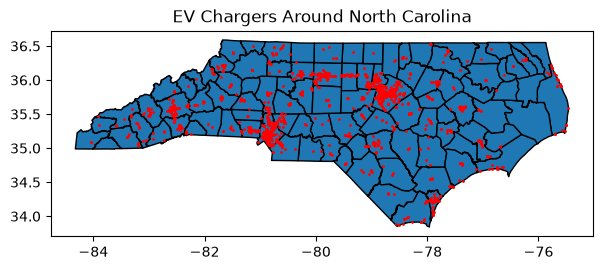

In [11]:
# Plotting all NC counties
fig, ax = plt.subplots(figsize=(7,7))
raw_counties.plot(ax=ax, edgecolor="black")
chargers.plot(ax=ax, markersize=1, c="red")
ax.set_title("EV Chargers Around North Carolina")
plt.show()

#### Filtering only counties near Chapel Hill
* 'Orange'
* 'Durham'
* 'Chatham'
* 'Alamance
* 'Person'
* 'Caswell'

In [12]:
# Filtering only columns of interest
counties = raw_counties[["NAME","geometry"]].copy()

In [13]:
# Filtering only rows of interest
counties_near_chap = counties[(counties['NAME'] == "Orange") | 
                     (counties['NAME'] == "Durham") | 
                     (counties['NAME'] == "Chatham") | 
                     (counties['NAME'] == "Alamance") | 
                     (counties['NAME'] == "Person") | 
                     (counties['NAME'] == "Caswell")].copy()

print(counties_near_chap)
print(type(counties_near_chap))

        NAME                                           geometry
0   Alamance  POLYGON ((-79.25882 36.17252, -79.25752 36.237...
16   Caswell  POLYGON ((-79.3646 36.5413, -79.36495 36.54131...
18   Chatham  POLYGON ((-79.0163 35.86322, -79.02524 35.8628...
31    Durham  POLYGON ((-78.80234 36.2358, -78.80268 36.2358...
67    Orange  POLYGON ((-78.9713 36.12121, -78.96626 36.15, ...
72    Person  POLYGON ((-78.79628 36.54175, -78.79662 36.541...
<class 'geopandas.geodataframe.GeoDataFrame'>


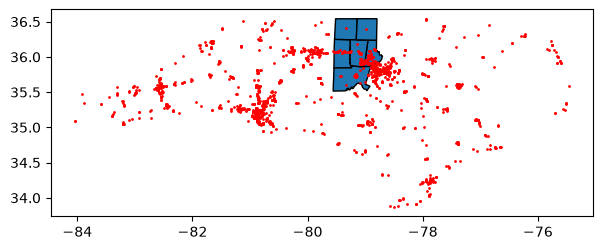

In [14]:
# Plotting only counties near Chapel Hill
fig, ax = plt.subplots(figsize=(7,7))
counties_near_chap.plot(ax=ax, edgecolor="black")
chargers.plot(ax=ax, markersize=1, c="red")
plt.show()

#### Finding chargers within selected counties

In [15]:
# make a "within" spatial selection 
chap_area = counties_near_chap.geometry.union_all()

near_chap = chargers.geometry.within(chap_area)

near_chap

0       False
1       False
2       False
3       False
4       False
        ...  
1879    False
1880    False
1881    False
1882    False
1883    False
Length: 1884, dtype: bool

In [16]:
chargers[near_chap]

,station_name,geometry
6,Neal's Garage,POINT (-78.9214 36.01)
17,Carolina Nissan,POINT (-79.50374 36.06368)
25,Michael Jordan Nissan,POINT (-78.95687 35.97076)
42,Orange County - Robert and Pearl Seymour Center,POINT (-79.06335 35.95063)
43,Orange County - Durham Technical Community Col...,POINT (-79.09323 36.04236)
...,...,...
1819,Avalon Townhomes at Brier Creek,POINT (-78.80857 35.92353)
1832,Durham County North Library,POINT (-78.91444 36.08762)
1841,Knoll at Briar Chapel - Tesla Destination,POINT (-79.08794 35.815)
1842,Chatham Park YMCA - Tesla Destination,POINT (-79.14352 35.73562)


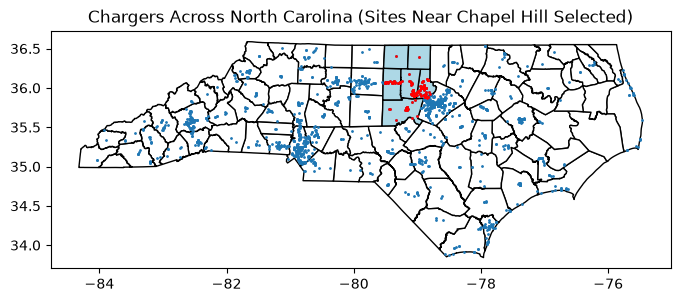

In [17]:
fig, ax = plt.subplots(figsize=(8,7))
counties.plot(ax=ax, color="white", edgecolor="black")
counties_near_chap.plot(ax=ax, color="lightblue", edgecolor="black")
chargers.plot(ax=ax, markersize=1)
chargers[near_chap].plot(ax=ax, markersize=1, c='red')
ax.set_title("Chargers Across North Carolina (Sites Near Chapel Hill Selected)")
plt.show()

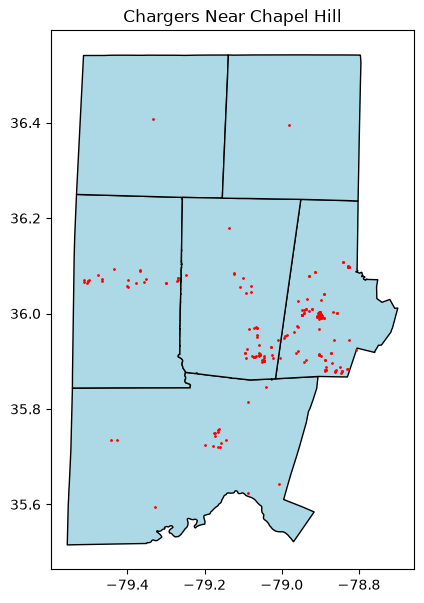

In [18]:
fig, ax = plt.subplots(figsize=(8,7))
counties_near_chap.plot(ax=ax, color="lightblue", edgecolor="black")
chargers[near_chap].plot(ax=ax, markersize=1, c='red')
ax.set_title("Chargers Near Chapel Hill")
plt.show()

#### Chapel Hill

In [19]:
# Filtering only Orange Ccounty
orange = counties[(counties['NAME'] == "Orange")].copy()

print(orange)

      NAME                                           geometry
67  Orange  POLYGON ((-78.9713 36.12121, -78.96626 36.15, ...


In [20]:
# make a "within" spatial selection 
orange_area = orange.geometry.union_all()

orange_mask = chargers.geometry.within(orange_area)

orange_chargers = chargers[orange_mask].copy()

orange_chargers

,station_name,geometry
42,Orange County - Robert and Pearl Seymour Center,POINT (-79.06335 35.95063)
43,Orange County - Durham Technical Community Col...,POINT (-79.09323 36.04236)
51,Eno River Parking Deck,POINT (-79.10021 36.07362)
60,UNC RAMSHEAD 1,POINT (-79.04568 35.90607)
61,UNC CARDINAL DECK 1,POINT (-79.05245 35.90333)
68,Mills Rentals Office,POINT (-79.05248 35.89739)
77,UNC CRAIGE DECK,POINT (-79.04771 35.90257)
105,PIEDMONT EMC PEMC,POINT (-79.08071 36.04555)
120,TOC EV STATIONS TOWNHALL,POINT (-79.0775 35.91116)
198,"The Franklin Hotel Chapel Hill, Curio Collecti...",POINT (-79.06013 35.91112)


#### Counts

In [21]:
print("EV chargers in NC:", len(chargers))
print("EV chargers near Chapel Hill:", len(chargers[near_chap]))
print("EV chargers in Orange County:", len(orange_chargers))

EV chargers in NC: 1884
EV chargers near Chapel Hill: 207
EV chargers in Orange County: 50


### Layer 2: Chargers Near Major Roads (Buffers)

In [22]:
# Read data
raw_roads = gpd.read_file("data/roads.geojson")

raw_roads

,OBJECTID,Division,MaintCntyCode,RouteID,RouteClass,RouteNumber,RouteQualifier,RouteInventory,RouteName,BeginMP,EndMP,RouteMaintCode,Shape_Length,geometry
0,1,13,011,10000026011,1,26,0,0,I-26,0.000000,29.167218,System,56265.394382,MULTILINESTRING Z ((950413.442 761781.527 1964...
1,2,14,045,10000026045,1,26,0,0,I-26,0.000000,17.459971,System,89044.485587,MULTILINESTRING Z ((947047.37 633980.63 2181.6...
2,3,13,057,10000026057,1,26,0,0,I-26,0.000000,12.606170,System,66456.001110,MULTILINESTRING Z ((946481.25 821340.56 3756.6...
3,4,14,075,10000026075,1,26,0,0,I-26,0.000000,13.123533,System,69212.403700,MULTILINESTRING Z ((1000455.242 564424.433 185...
4,5,7,001,10000040001,1,40,0,0,I-40,0.000000,16.012866,System,84492.495642,MULTILINESTRING Z ((1840729.024 842228.554 588...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810,811,8,077,29600074077,2,74,9,6,US-74 BUS,0.000000,14.566867,System,46860.713751,MULTILINESTRING Z ((1806427.07 407793.96 335.9...
811,812,8,083,29600074083,2,74,9,6,US-74 BUS,8.601984,9.082984,System,2537.367354,MULTILINESTRING Z ((1850065.85 376994.17 230.9...
812,813,1,037,29600158037,2,158,9,6,US-158 BUS,2.360000,2.385000,System,133.881949,"MULTILINESTRING Z ((2661160.5 975024.69 15.3, ..."
813,814,8,076,29600220076,2,220,9,6,US-220 BUS,15.463677,15.525600,System,326.714628,MULTILINESTRING Z ((1757595.067 706027.36 855....


In [23]:
# Identify CRS
raw_roads.crs

<Compound CRS: EPSG:8768>
Name: NAD83 / North Carolina (ftUS) + NAVD88 height (ftUS)
Axis Info [cartesian|vertical]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
- H[up]: Gravity-related height (US survey foot)
Area of Use:
- name: United States (USA) - North Carolina - counties of Alamance; Alexander; Alleghany; Anson; Ashe; Avery; Beaufort; Bertie; Bladen; Brunswick; Buncombe; Burke; Cabarrus; Caldwell; Camden; Carteret; Caswell; Catawba; Chatham; Cherokee; Chowan; Clay; Cleveland; Columbus; Craven; Cumberland; Currituck; Dare; Davidson; Davie; Duplin; Durham; Edgecombe; Forsyth; Franklin; Gaston; Gates; Graham; Granville; Greene; Guilford; Halifax; Harnett; Haywood; Henderson; Hertford; Hoke; Hyde; Iredell; Jackson; Johnston; Jones; Lee; Lenoir; Lincoln; Macon; Madison; Martin; McDowell; Mecklenburg; Mitchell; Montgomery; Moore; Nash; New Hanover; Northampton; Onslow; Orange; Pamlico; Pasquotank; Pender; Perquimans; Person; Pitt; Polk; Randolph; Richmond

In [24]:
# Transform road crs
roads_6543 = raw_roads.to_crs(epsg=6543)
roads_6543.crs

<Projected CRS: EPSG:6543>
Name: NAD83(2011) / North Carolina (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - North Carolina - counties of Alamance; Alexander; Alleghany; Anson; Ashe; Avery; Beaufort; Bertie; Bladen; Brunswick; Buncombe; Burke; Cabarrus; Caldwell; Camden; Carteret; Caswell; Catawba; Chatham; Cherokee; Chowan; Clay; Cleveland; Columbus; Craven; Cumberland; Currituck; Dare; Davidson; Davie; Duplin; Durham; Edgecombe; Forsyth; Franklin; Gaston; Gates; Graham; Granville; Greene; Guilford; Halifax; Harnett; Haywood; Henderson; Hertford; Hoke; Hyde; Iredell; Jackson; Johnston; Jones; Lee; Lenoir; Lincoln; Macon; Madison; Martin; McDowell; Mecklenburg; Mitchell; Montgomery; Moore; Nash; New Hanover; Northampton; Onslow; Orange; Pamlico; Pasquotank; Pender; Perquimans; Person; Pitt; Polk; Randolph; Richmond; Robeson; Rockingham; Rowan; Rutherford; Sampson; Scotland; Stanly; Stoke

In [25]:
# Transforming the chargers and counties
chargers_6543 = chargers.to_crs(epsg=6543)
counties_6543 = counties.to_crs(epsg=6543)

In [26]:
# Filtering only columns of interest
roads = roads_6543[["RouteName", "geometry"]].copy()
roads

,RouteName,geometry
0,I-26,MULTILINESTRING Z ((950413.442 761781.527 1964...
1,I-26,MULTILINESTRING Z ((947047.37 633980.63 2181.6...
2,I-26,MULTILINESTRING Z ((946481.25 821340.56 3756.6...
3,I-26,MULTILINESTRING Z ((1000455.242 564424.433 185...
4,I-40,MULTILINESTRING Z ((1840729.024 842228.554 588...
...,...,...
810,US-74 BUS,MULTILINESTRING Z ((1806427.07 407793.96 335.9...
811,US-74 BUS,MULTILINESTRING Z ((1850065.85 376994.17 230.9...
812,US-158 BUS,"MULTILINESTRING Z ((2661160.5 975024.69 15.3, ..."
813,US-220 BUS,MULTILINESTRING Z ((1757595.067 706027.36 855....


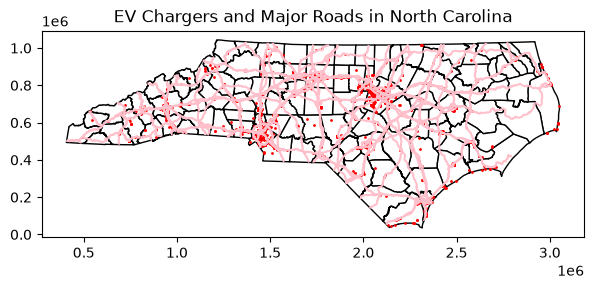

In [27]:
fig, ax = plt.subplots(figsize=(7,7))
counties_6543.plot(ax=ax, color="white", edgecolor="black")
roads.plot(ax=ax, color="pink")
chargers_6543.plot(ax=ax, color="red", markersize=1)
ax.set_title("EV Chargers and Major Roads in North Carolina")
plt.show()

#### Create buffers around roads

In [28]:
# 1 mile buffer
road_buffers = roads.buffer(5280)

road_buffers

0      MULTIPOLYGON (((945186.187 760663.201, 945176....
1      POLYGON ((943513.566 629538.76, 943312.404 629...
2      POLYGON ((942101.695 811605.881, 940816.704 81...
3      POLYGON ((999224.587 559232.346, 999223.764 55...
4      POLYGON ((1839808.956 847424.871, 1839808.53 8...
                             ...                        
810    MULTIPOLYGON (((1799574.934 405500.765, 179952...
811    POLYGON ((1844939.05 374375.341, 1844824.294 3...
812    POLYGON ((2661201.279 980300.009, 2661321.127 ...
813    POLYGON ((1754275.663 701587.518, 1754212.302 ...
814    POLYGON ((1263967.352 963678.748, 1263855.51 9...
Length: 815, dtype: geometry

In [29]:
# Combine road buffers
road_area = road_buffers.union_all()

In [30]:
# Chargers intersect
near_roads = chargers_6543.geometry.intersects(road_area)
near_roads

0        True
1        True
2        True
3        True
4        True
        ...  
1879    False
1880    False
1881     True
1882     True
1883     True
Length: 1884, dtype: bool

In [31]:
# Chargers near roads
chargers_near_roads = chargers_6543[near_roads]
chargers_near_roads

,station_name,geometry
0,City of Raleigh - Municipal Building,POINT (2105750.865 738429.986)
1,City of Raleigh - Downtown,POINT (2106107.088 736951.262)
2,Modern Nissan - Concord,POINT (1516389.819 601580.617)
3,Marriott Hotel - Underground Deck,POINT (2107231.761 736420.627)
4,City of Raleigh - Performing Arts Center Deck,POINT (2106345.181 736322.045)
...,...,...
1872,Camden Ballantyne,POINT (1448750.102 479683.025)
1874,Holiday Inn Express & Suites Raleigh West - Le...,POINT (2076016.133 742493.409)
1881,"Salisbury, NC Rechargery Relay @ Circle K -Row...",POINT (1557778.092 687938.57)
1882,PPS MAASTATION1,POINT (1439600.797 530353.453)


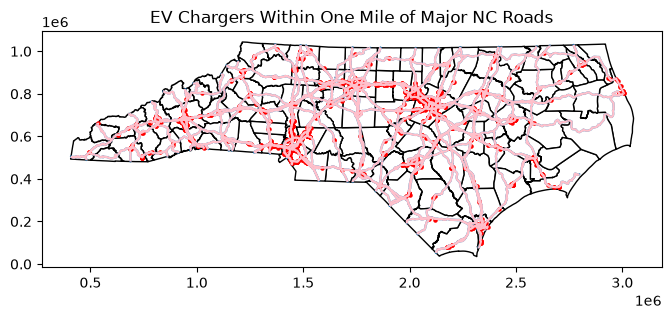

In [32]:
fig, ax = plt.subplots(figsize=(8,7))
counties_6543.plot(ax=ax, color="white", edgecolor="black")
road_buffers.plot(ax=ax, alpha=0.7)
roads.plot(ax=ax, color="pink")
chargers_near_roads.plot(ax=ax, markersize=5, color="red")
ax.set_title("EV Chargers Within One Mile of Major NC Roads")
plt.show()

#### EV Chargers + Major Roads + Chapel Hill Counties

In [33]:
# Chap counties to 6543
chap_counties_6543 = counties_near_chap.to_crs(epsg=6543)

In [34]:
# combine
chap_area_6543 = chap_counties_6543.geometry.union_all()

In [35]:
# chargers near roads in Chap
near_chap_roads = chargers_near_roads.geometry.within(chap_area_6543)

near_chap_roads

0       False
1       False
2       False
3       False
4       False
        ...  
1872    False
1874    False
1881    False
1882    False
1883    False
Length: 1477, dtype: bool

In [36]:
chap_road_chargers = chargers_near_roads[near_chap_roads]

chap_road_chargers

,station_name,geometry
6,Neal's Garage,POINT (2023245.48 822547.412)
17,Carolina Nissan,POINT (1851112.214 842457.359)
25,Michael Jordan Nissan,POINT (2012761.867 808255.333)
43,Orange County - Durham Technical Community Col...,POINT (1972437.095 834331.412)
51,Eno River Parking Deck,POINT (1970384.987 845713.03)
...,...,...
1819,Avalon Townhomes at Brier Creek,POINT (2056679.624 791117.782)
1832,Durham County North Library,POINT (2025281.114 850805.461)
1841,Knoll at Briar Chapel - Tesla Destination,POINT (1973928.922 751567.321)
1842,Chatham Park YMCA - Tesla Destination,POINT (1957408.121 722694.933)


In [37]:
# roads near chap
roads_near_chap = roads[roads.geometry.intersects(chap_area_6543)].copy()

road_buffers_near_chap = roads_near_chap.buffer(5280)

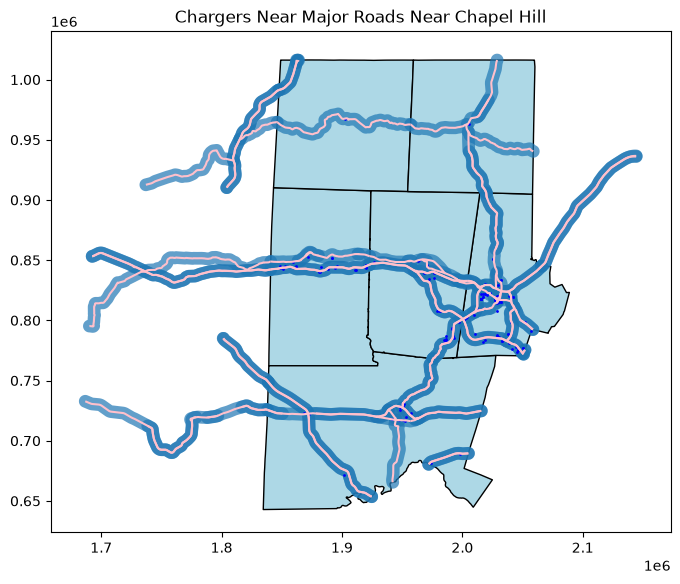

In [38]:
# plotting charger near roads in chapel hill
fig, ax = plt.subplots(figsize=(8,7))
chap_counties_6543.plot(ax=ax, color="lightblue", edgecolor="black")
road_buffers_near_chap.plot(ax=ax, alpha=0.7)
roads_near_chap.plot(ax=ax, color="pink")
chap_road_chargers.plot(ax=ax, markersize=1, c='blue')
ax.set_title("Chargers Near Major Roads Near Chapel Hill")
plt.show()

#### Counts

In [39]:
print("Total EV chargers in NC:", len(chargers_6543))
print("EV chargers within 1 mile of a major road:", len(chargers_near_roads))
print("EV chargers near major roads near Chapel Hill:", len(chap_road_chargers))

Total EV chargers in NC: 1884
EV chargers within 1 mile of a major road: 1477
EV chargers near major roads near Chapel Hill: 161


### Layer 3: Chargers Near UNC Parking (Distance & Shortest Line)

In [40]:
# load data
unc_parking = gpd.read_file("data/unc_parking.geojson")

unc_parking.head()

,OBJECTID,LOT_NAME,LOT_NUMBER,ZONE_ID,LOC_ID,NOTES,AWC_RANK,SHAPE__Area,SHAPE__Length,geometry
0,1,South Substation,P188,NaN,NaN,NaN,None,2463.351562,385.735218,"POLYGON ((-79.02931 35.90008, -79.02929 35.900..."
1,2,Finley Golf Course,P257,NaN,NaN,NaN,None,13340.324219,1523.903611,"POLYGON ((-79.02281 35.89593, -79.02285 35.895..."
2,3,High Sch Athletic Ctr,P254,NaN,NaN,NaN,None,1281.804688,199.598189,"POLYGON ((-79.02032 35.9003, -79.02029 35.9004..."
3,4,General Administration,P242,NaN,NaN,NaN,None,16360.726562,1989.819302,"POLYGON ((-79.03056 35.90941, -79.03058 35.909..."
4,5,EHS Parking Lot,P215,NaN,NaN,NaN,None,1783.839844,325.295522,"POLYGON ((-79.05948 35.93378, -79.05931 35.933..."


In [41]:
unc_parking.columns

Index(['OBJECTID', 'LOT_NAME', 'LOT_NUMBER', 'ZONE_ID', 'LOC_ID', 'NOTES',
       'AWC_RANK', 'SHAPE__Area', 'SHAPE__Length', 'geometry'],
      dtype='str')

In [42]:
unc_parking.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [43]:
# looking at parking lot names
for value in sorted(unc_parking["LOT_NAME"].dropna().unique()):
    print(value)

200 FINLEY ROAD
204 FINLEY GOLF CRSE RD
208 FINLEY GOLF CRSE RD
216 FINLEY GOLF CRSE RD
220 FINLEY GOLF COURSE RD
725 MLK
ALDERMAN
AMBULATORY CARE
AOB-UNC
ARBORETUM LANE
ATM DRIVE
AVERY
AVERY DRIVE
Anderson Pavillion
BAITY HILL
BATTLE LANE
BEARD
BELL TOWER DECK
BELL TOWER DRIVE
BERNARD STREET
BIOINFORMATICS
BLYTHE DRIVE
BOLIN CREEK
BOSHAMER
BOTANICAL GARDEN
BOUNDARY STREET
BOWLES
BOWLES DRIVE
BRANSON OVERFLOW
BRANSON STREET
BRINKHAUS-BULLITT
BSRC NEUROSCIENCES
BUSINESS SCHOOL DECK
BYNUM
Brooks Hall
CALDWELL
CAMERON AVENUE
CAMERON/GRAHAM
CANCER HOSP LOT
CARDINAL DECK
CARMICHAEL DRIVE
CAROLINA INN I & II
CAROLINA NORTH
CG-Helipad
CHANCELLORS RESIDENCE
CHAPEL HILL NORTH
CHATHAM PARK AND RIDE
CHILDREN'S & WOMEN'S
COATES
COBB
COBB DECK
COGENERATION
COKER/MITCHELL
COLUMBIA STREET
COMPOUND
CONE TENNIS
COUNTRY CLUB
CRAIGE
CRAIGE DECK - DECK
CRAIGE DRIVE
Carolina North Operations
Chapman Golf Team Facility 
Connor
Crescent Lot
DAVIS LIBRARY LOADING
DAVIS TUNNEL
DEAN E. SMITH CENTER
DENTAL CIRCL

In [44]:
# select Rams Head deck
rams_head = unc_parking[unc_parking["LOT_NAME"] == "RAMS HEAD DECK"].copy()

rams_head

,OBJECTID,LOT_NAME,LOT_NUMBER,ZONE_ID,LOC_ID,NOTES,AWC_RANK,SHAPE__Area,SHAPE__Length,geometry
50,51,RAMS HEAD DECK,P392,RD/Vi*,NaN,NaN,None,15465.710938,547.901682,"POLYGON ((-79.04673 35.9057, -79.04624 35.9065..."


In [45]:
# check and change crs
rams_head_6543 = rams_head.to_crs(epsg=6543)
print(rams_head_6543.crs)

orange_chargers_6543 = orange_chargers.to_crs(epsg=6543)
print(orange_chargers_6543.crs)

EPSG:6543
EPSG:6543


In [46]:
# calculate distance of chargers from rams head
rams_geom = rams_head_6543.geometry.iloc[0]

campus_chargers = orange_chargers_6543.copy()

campus_chargers["distance_to_rams"] = (campus_chargers.geometry.distance(rams_geom))

campus_chargers

,station_name,geometry,distance_to_rams
42,Orange County - Robert and Pearl Seymour Center,POINT (1981248.448 800932.338),16797.634288
43,Orange County - Durham Technical Community Col...,POINT (1972437.095 834331.412),51325.955394
51,Eno River Parking Deck,POINT (1970384.987 845713.03),62848.018513
60,UNC RAMSHEAD 1,POINT (1986472.44 784708.701),0.000000
61,UNC CARDINAL DECK 1,POINT (1984467.019 783713.034),1900.487832
68,Mills Rentals Office,POINT (1984457.287 781550.099),3470.487908
77,UNC CRAIGE DECK,POINT (1985869.767 783436.044),1153.734381
105,PIEDMONT EMC PEMC,POINT (1976140.685 835487.964),51583.468881
120,TOC EV STATIONS TOWNHALL,POINT (1977051.476 786568.085),9326.070310
198,"The Franklin Hotel Chapel Hill, Curio Collecti...",POINT (1982194.57 786549.231),4430.949137


In [47]:
# distance in miles
campus_chargers["distance_miles"] = (campus_chargers["distance_to_rams"]/5280)

In [48]:
# show values
campus_chargers.sort_values("distance_to_rams")

,station_name,geometry,distance_to_rams,distance_miles
60,UNC RAMSHEAD 1,POINT (1986472.44 784708.701),0.000000,0.000000
77,UNC CRAIGE DECK,POINT (1985869.767 783436.044),1153.734381,0.218510
1777,UNC SOB-6,POINT (1986151.442 782870.239),1634.596647,0.309583
1776,UNC SOB-5,POINT (1986183.985 782795.238),1706.152846,0.323135
1773,UNC SOB-2,POINT (1986240.819 782732.966),1764.534240,0.334192
1775,UNC SOB-4,POINT (1986216.827 782727.153),1771.667223,0.335543
1774,UNC SOB-3,POINT (1986227.19 782721.324),1776.874119,0.336529
628,UNC SOB-1,POINT (1986348.611 782707.435),1788.103659,0.338656
629,UNC COBB DECK,POINT (1986645.413 786720.141),1829.647678,0.346524
61,UNC CARDINAL DECK 1,POINT (1984467.019 783713.034),1900.487832,0.359941


In [49]:
# using shortest_line()
charger_to_rams = campus_chargers.geometry.shortest_line(rams_geom)

charger_to_rams

42      LINESTRING (1981248.448 800932.338, 1986322.14...
43      LINESTRING (1972437.095 834331.412, 1986322.14...
51      LINESTRING (1970384.987 845713.03, 1986322.147...
60      LINESTRING (1986472.44 784708.701, 1986472.44 ...
61      LINESTRING (1984467.019 783713.034, 1986161.69...
68      LINESTRING (1984457.287 781550.099, 1986161.69...
77      LINESTRING (1985869.767 783436.044, 1986326.77...
105     LINESTRING (1976140.685 835487.964, 1986322.14...
120     LINESTRING (1977051.476 786568.085, 1986161.69...
198     LINESTRING (1982194.57 786549.231, 1986202.999...
270     LINESTRING (1978919.868 785934.036, 1986161.69...
370     LINESTRING (1976488.704 839620.883, 1986322.14...
577     LINESTRING (1983102.954 786915.219, 1986322.14...
583     LINESTRING (1971591.872 788469.35, 1986161.696...
607     LINESTRING (1982908.783 788515.193, 1986322.14...
628     LINESTRING (1986348.611 782707.435, 1986326.77...
629     LINESTRING (1986645.413 786720.141, 1986322.14...
646     LINEST

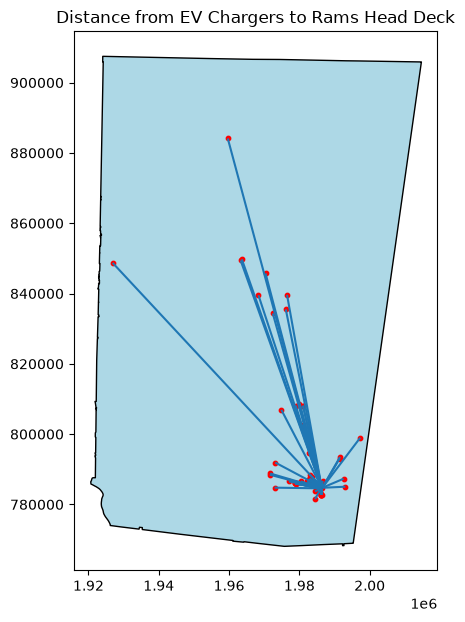

In [50]:
fig, ax = plt.subplots(figsize=(8,7))
orange.to_crs(epsg=6543).plot(ax=ax, color="lightblue", edgecolor="black")
charger_to_rams.plot(ax=ax)
campus_chargers.plot(ax=ax, color="red", markersize=10)
rams_head_6543.plot(ax=ax, color="black")
ax.set_title("Distance from EV Chargers to Rams Head Deck")
plt.show()

### Layer 4: Joining Chargers Data With EV Ownership Data (Attribute Join)

In [51]:
# load data
raw_ev_owner = pd.read_csv("data/evs.csv")

raw_ev_owner.head()

,County,Electric,Electric: Difference,Plug-In Hybrid,Plug-In Hybrid: Difference,Hybrid,Hybrid: Difference,All Hybrids,All Hybrids: Difference,Alternative,Alternative: Difference,Gas,Gas: Difference,Diesel,Diesel: Difference
0,Yancey,89,-2,60,0,542,1,602,1,NaN,NaN,"17,828",-15,"1,789",-11
1,Yadkin,110,10,49,2,819,13,868,15,11.0,2.0,"36,956",8,"3,291",-17
2,Wilson,269,7,73,7,"1,826",46,"1,899",53,1.0,0.0,"63,419",-66,"3,851",-10
3,Wilkes,205,3,62,3,"1,718",35,"1,780",38,2.0,0.0,"62,043",68,"4,803",11
4,Wayne,438,16,141,10,"2,495",69,"2,636",79,3.0,-1.0,"94,998",-107,"4,920",-29


In [60]:
# select only necessary columns
evs = raw_ev_owner[["County", "Electric"]].copy()
evs["NAME"] = evs["County"]
ev_owners = evs[["NAME", "Electric"]].copy()
ev_owners

,NAME,Electric
0,Yancey,89
1,Yadkin,110
2,Wilson,269
3,Wilkes,205
4,Wayne,438
...,...,...
95,Ashe,111
96,Anson,40
97,Alleghany,42
98,Alexander,162


In [53]:
# view counties data
counties_6543

,NAME,geometry
0,Alamance,"POLYGON ((1923604.342 881802.091, 1924049.742 ..."
1,Alexander,"POLYGON ((1374326.86 744227.342, 1374778.907 7..."
2,Alleghany,"POLYGON ((1336457.549 959892.73, 1336609.288 9..."
3,Anson,"POLYGON ((1618558.992 528615.286, 1618548.221 ..."
4,Ashe,"POLYGON ((1269470.883 915478.909, 1273365.92 9..."
...,...,...
95,Wayne,"POLYGON ((2297704.652 669585.811, 2297606.978 ..."
96,Wilkes,"POLYGON ((1319003.916 828582.081, 1319039.919 ..."
97,Wilson,"POLYGON ((2350081.932 670058.039, 2350138.509 ..."
98,Yadkin,"POLYGON ((1557884.73 838963.611, 1557752.314 8..."


In [62]:
county_ev_ownership = counties_6543.merge(ev_owners, on="NAME", how="left")

county_ev_ownership

,NAME,geometry,Electric
0,Alamance,"POLYGON ((1923604.342 881802.091, 1924049.742 ...","1,317"
1,Alexander,"POLYGON ((1374326.86 744227.342, 1374778.907 7...",162
2,Alleghany,"POLYGON ((1336457.549 959892.73, 1336609.288 9...",42
3,Anson,"POLYGON ((1618558.992 528615.286, 1618548.221 ...",40
4,Ashe,"POLYGON ((1269470.883 915478.909, 1273365.92 9...",111
...,...,...,...
95,Wayne,"POLYGON ((2297704.652 669585.811, 2297606.978 ...",438
96,Wilkes,"POLYGON ((1319003.916 828582.081, 1319039.919 ...",205
97,Wilson,"POLYGON ((2350081.932 670058.039, 2350138.509 ...",269
98,Yadkin,"POLYGON ((1557884.73 838963.611, 1557752.314 8...",110


### Analysis: Joining County EV Ownership with Chargers in Each County (Spatial Join)

In [73]:
# spatial join
evs_chargers = gpd.sjoin(chargers_6543, county_ev_ownership, predicate='within')
evs_chargers

,station_name,geometry,index_right,NAME,Electric
0,City of Raleigh - Municipal Building,POINT (2105750.865 738429.986),91,Wake,"30,151"
1,City of Raleigh - Downtown,POINT (2106107.088 736951.262),91,Wake,"30,151"
2,Modern Nissan - Concord,POINT (1516389.819 601580.617),12,Cabarrus,"3,701"
3,Marriott Hotel - Underground Deck,POINT (2107231.761 736420.627),91,Wake,"30,151"
4,City of Raleigh - Performing Arts Center Deck,POINT (2106345.181 736322.045),91,Wake,"30,151"
...,...,...,...,...,...
1879,WCPSS FELTON GROVE 3,POINT (2055982.935 704966.119),91,Wake,"30,151"
1880,WCPSS FELTON GROVE 2,POINT (2056002.816 704973.801),91,Wake,"30,151"
1881,"Salisbury, NC Rechargery Relay @ Circle K -Row...",POINT (1557778.092 687938.57),79,Rowan,687
1882,PPS MAASTATION1,POINT (1439600.797 530353.453),59,Mecklenburg,"19,692"


## AI Usage
**Section: Filtering only rows of interest**\
Looked up why using "OR" was not selecting the rows of interest to learn "|" is used for pandas (Gemini)

**Section: make a "within" spatial selection**\
Received a warning message that my 'near_chap' object had multiple polygons so the performance of ".within" will be different than expected. Added the new 'chap_area' as a union of all polygons selected (ChatGPT)

**Section: Combine road buffers**\
After getting an error message, checked with AI to realize I needed to use the "union_all()" methond again to combine each of the road buffers into one geometry to compare with the chargers (ChatGPT)

**Section: roads near chap**\
Clarify how to select only the roads near Chapel Hill. Guided me to use ".intersects" instead of ".within" (ChatGPT)

**Section: looking at parking lot names**\
I wanted to view all of the names of each lot so I can select Rams Head but the code only displayed a few when only using ".unique", so I used AI to explain how to print all names (ChatGPT)